In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt


In [2]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_model(
    pooling_type="max",      # "max", "avg", None
    use_dropout=False,
    kernel_size=(3, 3),
    stride=1,
    filters=[32, 64, 128]
):
    model = models.Sequential()

    # Conv Layer 1
    model.add(layers.Conv2D(filters[0], kernel_size, strides=stride,
                            activation='relu', input_shape=(28,28,1)))
    if pooling_type == "max":
        model.add(layers.MaxPooling2D((2,2)))
    elif pooling_type == "avg":
        model.add(layers.AveragePooling2D((2,2)))

    # Conv Layer 2
    model.add(layers.Conv2D(filters[1], kernel_size, strides=stride, activation='relu'))
    if pooling_type == "max":
        model.add(layers.MaxPooling2D((2,2)))
    elif pooling_type == "avg":
        model.add(layers.AveragePooling2D((2,2)))

    # Conv Layer 3
    model.add(layers.Conv2D(filters[2], kernel_size, strides=stride, activation='relu'))

    model.add(layers.Flatten())

    # Dense Layers (4 Dense)
    model.add(layers.Dense(256, activation='relu'))
    if use_dropout:
        model.add(layers.Dropout(0.5))

    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(32, activation='relu'))

    # Output
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


In [4]:
model = build_model(
    pooling_type="max",
    use_dropout=True,
    kernel_size=(3,3),
    stride=1,
    filters=[32, 64, 128]
)

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.5860 - loss: 1.0996 - val_accuracy: 0.8235 - val_loss: 0.4468
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8290 - loss: 0.4567 - val_accuracy: 0.8646 - val_loss: 0.3613
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8662 - loss: 0.3660 - val_accuracy: 0.8872 - val_loss: 0.3075
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8850 - loss: 0.3138 - val_accuracy: 0.8808 - val_loss: 0.3266
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8943 - loss: 0.2886 - val_accuracy: 0.8965 - val_loss: 0.2795
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9066 - loss: 0.2565 - val_accuracy: 0.9040 - val_loss: 0.2596
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9148 - loss: 0.2327 - val_accuracy: 0.9056 - val_loss: 0.2575
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9193 - loss: 0.2189 - val_accuracy: 

In [5]:
def plot_history(history, title="Model"):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


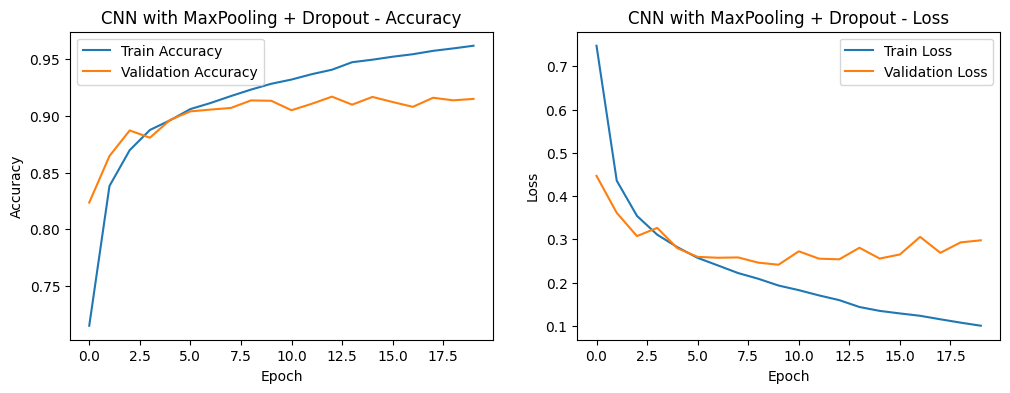

In [6]:
plot_history(history, "CNN with MaxPooling + Dropout")
